# Load

In [5]:
import torch
import math
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace, ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

from urllib.request import urlopen
from tqdm import tqdm

random_seed = 42
torch.manual_seed(random_seed)

## Import Text
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urlopen(url).read().decode("utf-8")
# print(text[:100])

# def preprocess(text):
#     return text.replace(" ", " Ġ")
# text = preprocess(text)
words = text.split()

# print(words[:20])
# print(type(text))
# print(text)
print('text length:', len(text)) # 1115394

text length: 1115394


# Tokenize

## Option 1: Use BPE Tokenizer Package

In [9]:
# Initialize tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = ByteLevel()
tokenizer.decoder = ByteLevelDecoder()

# Trainer

vocab_size = 500
trainer = BpeTrainer(
    vocab_size=vocab_size,
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"]
)

# Train directly from text (no file)
tokenizer.train_from_iterator([text], trainer)

tokenized_text_ids = tokenizer.encode(text).ids
vocab_dict = tokenizer.get_vocab()
# print("Vocab dict:", vocab_dict)
print("Vocabulary size:", len(vocab_dict))

encoded = tokenizer.encode("This is a test")
print(encoded.tokens)
print(tokenizer.decode(encoded.ids))




Vocabulary size: 500
['Ġ', 'Th', 'is', 'Ġis', 'Ġa', 'Ġt', 'est']
 This is a test


## Option 2: create my own vocabs

In [6]:
################################
##  Create Merges and Vocabs  ##
################################

vocab_size = 500

## Compute base vocabulary
vocab = []

for letter in text:
    if letter not in vocab:
        vocab.append(letter)
vocab.sort()
# print('vocab', vocab)


## compute word frequencies
from collections import defaultdict
word_freqs = defaultdict(int)

for word in words:
    word_freqs[word] += 1
# print('word_freqs', word_freqs)


## create splits
splits = {word: [c for c in word] for word in word_freqs.keys()}
# for i, key in enumerate(splits.keys()):
#     print(f"{key}: {splits[key]}")
#     if i >= 5:
#         break
    
## compute pair frequencies
def compute_pair_freqs(splits):
    pair_freqs = defaultdict(int)
    for word, freq in word_freqs.items():
        split = splits[word]
        if len(split) == 1:
            continue
        for i in range(len(split) - 1):
            pair = (split[i], split[i + 1])
            pair_freqs[pair] += freq
    return pair_freqs

pair_freqs = compute_pair_freqs(splits)

# for i, key in enumerate(pair_freqs.keys()):
#     print(f"{key}: {pair_freqs[key]}")
#     if i >= 5:
#         break

## find the best pair
def find_best_pair(pair_freqs):
     best_pair = ""
     max_freq = None
     for pair, freq in pair_freqs.items():
         if max_freq is None or max_freq < freq:
             best_pair = pair
             max_freq = freq
     return best_pair, max_freq

best_pair, max_freq = find_best_pair(pair_freqs)
print('best_pair', best_pair, 'max_freq', max_freq)

merges = {best_pair: best_pair[0] + best_pair[1]}
vocab.append(best_pair[0] + best_pair[1])

def merge_pair(a, b, splits):
    for word in word_freqs:
        split = splits[word]
        if len(split) == 1:
            continue

        i = 0
        while i < len(split) - 1:
            if split[i] == a and split[i + 1] == b:
                split = split[:i] + [a + b] + split[i + 2 :]
            else:
                i += 1
        splits[word] = split
    return splits

splits = merge_pair(best_pair[0], best_pair[1], splits)
print(splits['the'])


## big loop
pbar = tqdm(total=vocab_size - len(vocab))
while len(vocab) < vocab_size:
    pair_freqs = compute_pair_freqs(splits)
    best_pair, max_freq = find_best_pair(pair_freqs)
    splits = merge_pair(*best_pair, splits)
    merges[best_pair] = best_pair[0] + best_pair[1]
    vocab.append(best_pair[0] + best_pair[1])

    pbar.update(1)   # increment progress
pbar.close()

# print(merges) # dict: pair -> merge
# print(vocab) # list of tokens
# print(splits) # dict: word -> list of tokens

vocab_dict = {token: idx for idx, token in enumerate(vocab)}
# print(vocab_dict)

best_pair ('t', 'h') max_freq 22739
['th', 'e']


100%|██████████| 434/434 [00:21<00:00, 20.33it/s]


In [7]:
################################
##   Tokenize Original Text   ##
################################

def tokenize(words):
    splits = [[l for l in word] for word in words] # split of original text

    pbar = tqdm(merges.items(), desc="Applying merges")
    for pair, merge in pbar:
        for idx, split in enumerate(splits):
            i = 0
            while i < len(split) - 1:
                if split[i] == pair[0] and split[i + 1] == pair[1]:
                    split[i:i+2] = [merge] 
                else:
                    i += 1
            splits[idx] = split

    return sum(splits, [])

tokenized_text = tokenize(words)
print(tokenized_text[:20])

tokenized_text_ids = [vocab_dict[token] for token in tokenized_text]
print(tokenized_text_ids[:20])

Applying merges: 100%|██████████| 435/435 [00:28<00:00, 15.17it/s]


['First', 'C', 'it', 'i', 'z', 'en', ':', 'Be', 'fore', 'we', 'pro', 'ce', 'ed', 'an', 'y', 'f', 'ur', 'ther', ',', 'hear']
[427, 15, 91, 47, 64, 73, 10, 415, 328, 114, 307, 99, 108, 69, 63, 44, 141, 131, 6, 414]


# Sequence formatting

In [10]:
## Sequence formatting: Split tokenized text into overlapping fixed-length sequences

seq_length = 50
overlap = 25

sequences = []
for i in range(0, len(tokenized_text_ids) - seq_length + 1, overlap):
    sequences.append(tokenized_text_ids[i:i+seq_length])

# Create inputs and targets for next-token prediction
input_sequences = [seq[:-1] for seq in sequences]
target_sequences = [seq[1:] for seq in sequences]

inputs = torch.tensor(input_sequences)
targets = torch.tensor(target_sequences)


## Data split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(inputs, targets, test_size=0.2, random_state=random_seed)

print(f"Number of training sequences: {len(X_train)}")
print(f"Number of validation sequences: {len(X_val)}")
print(f"Sequence length: {X_train.shape[1]}")

Number of training sequences: 16548
Number of validation sequences: 4138
Sequence length: 49


In [ ]:
# Visualize Token embedding

'''
embedding = nn.Embedding(vocab_size, embedding_dim=64)

X_train_embeddings = embedding(X_train)
X_val_embeddings = embedding(X_val)

X_train_embeddings[0]
'''

tensor([[ 0.5468, -0.1942, -0.8640,  ...,  0.5170,  0.8042, -0.1333],
        [-1.2787, -0.0384,  1.9138,  ...,  3.0250,  1.3463,  0.8556],
        [-1.3799, -0.2103,  0.8919,  ..., -1.8040,  1.8377, -0.7219],
        ...,
        [ 1.3894, -1.4594,  0.7734,  ..., -0.6831,  0.2833, -0.7550],
        [ 0.9702, -1.7244,  1.6173,  ...,  1.2511, -1.9372, -1.2051],
        [-0.1345,  0.5260,  1.2341,  ...,  1.5608,  0.0496, -0.3332]],
       grad_fn=<SelectBackward0>)

# Implement a Tiny Transformer

Build a minimal Transformer-based language model including:
* Positional encoding (sinusoidal or RoPE if you want more challenges)
* Self-attention module
* Apply a causal mask to prevent the model from attending to future tokens
* Feed-forward network with residual connections and RMSnorm
* Train it using cross-entropy loss for next-token prediction

In [37]:
class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=512): # max_len: maximum sequence length
        super().__init__()
        pe = torch.zeros(max_len, dim) # position embeding matrix, shape (max_len, dim)

        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, dim, 2) * (-math.log(10000.0) / dim)
        ) # frequency for each dimension

        pe[:, 0::2] = torch.sin(position * div_term) # sin to even indices
        pe[:, 1::2] = torch.cos(position * div_term) # cos to odd indices

        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, C)
        # B = batch size (# of 'sentences'), T = sequence length / length of sentence, C = embedding dimension (dim)
        return x + self.pe[:x.size(1)]
    

# TransformerBlock
class RMSNorm(nn.Module): # root mean square layer normalization
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm = x.pow(2).mean(-1, keepdim=True)
        x = x * torch.rsqrt(norm + self.eps)
        return self.scale * x
    

class SelfAttention(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads

        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)  # (B, T, 3C)
        q, k, v = qkv.chunk(3, dim=-1)

        # reshape for multi-head
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # attention scores
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # causal mask
        mask = torch.tril(torch.ones(T, T, device=x.device))
        attn = attn.masked_fill(mask == 0, float('-inf'))

        attn = torch.softmax(attn, dim=-1)
        self.attn_weights = attn

        out = attn @ v  # (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out(out)
    

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x):
        return self.net(x)
    

class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, ff_hidden):
        super().__init__()
        self.attn = SelfAttention(dim, n_heads)
        self.ff = FeedForward(dim, ff_hidden)

        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # residual
        x = x + self.ff(self.norm2(x))    # residual
        return x


class TransformerLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_heads, n_layers, max_len=512):
        super().__init__()

        # token embedding
        self.token_emb = nn.Embedding(vocab_size, embedding_dim)
        # positional encoding
        self.pos_enc = PositionalEncoding(embedding_dim, max_len)
        # stack of transformer blocks
        self.blocks = nn.Sequential(*[TransformerBlock(embedding_dim, n_heads, embedding_dim * 4) for _ in range(n_layers)])
        # final layer norm
        self.norm = RMSNorm(embedding_dim)
        # output head
        self.head = nn.Linear(embedding_dim, vocab_size)

    def forward(self, x):
        
        # x: (B, T)
        x = self.token_emb(x)        # (B, T, C)
        x = self.pos_enc(x)
        x = self.blocks(x)
        x = self.norm(x)
        logits = self.head(x)        # (B, T, vocab_size)

        return logits

## Training

tensor([[119, 264,  13, 252,  60,  82, 134, 119, 130, 112, 111,  67, 211,  68,
         171,  66,  45, 375,  69,  87, 123, 113, 152, 467, 143, 433,  12,  67,
         211, 101,   8, 119, 264,   8, 104, 366,   8, 247, 264, 101, 197,   8,
          67,  20, 234,  80,  74, 311, 386]])
Sample token sequence used for attention heatmaps:  my lord; 'tis not my meaning
To raze one title of your honour out:
To you, my lord, I come, what lord you will,
From the most gra
Begin training...
step 0, train loss 6.3971, val loss 6.3670


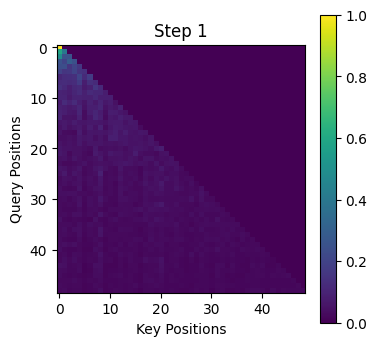

step 100, train loss 5.3571, val loss 5.3559
step 200, train loss 4.9883, val loss 4.9727
step 300, train loss 4.5073, val loss 4.5050
step 400, train loss 4.1853, val loss 4.1883


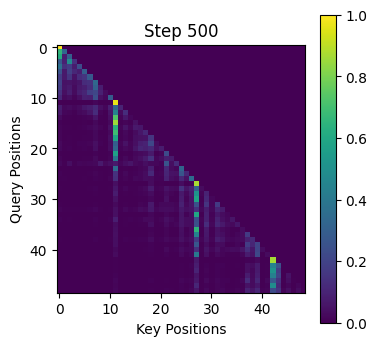

step 500, train loss 3.9683, val loss 3.9798
step 600, train loss 3.8655, val loss 3.8831
step 700, train loss 3.7499, val loss 3.7575
step 800, train loss 3.6620, val loss 3.6932
step 900, train loss 3.6227, val loss 3.6048


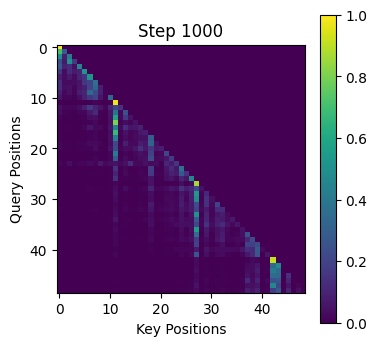

step 1000, train loss 3.5176, val loss 3.5984
step 1100, train loss 3.4800, val loss 3.5419
step 1200, train loss 3.4269, val loss 3.5144
step 1300, train loss 3.3948, val loss 3.4573
step 1400, train loss 3.3887, val loss 3.3878


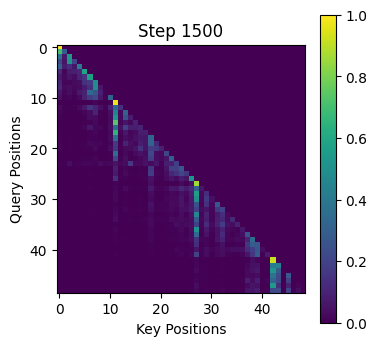

step 1500, train loss 3.3468, val loss 3.3865
step 1600, train loss 3.3366, val loss 3.3376
step 1700, train loss 3.2699, val loss 3.3084
step 1800, train loss 3.2597, val loss 3.3230
step 1900, train loss 3.2466, val loss 3.2626


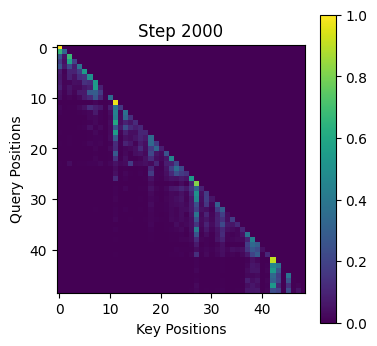

step 2000, train loss 3.2037, val loss 3.2548
step 2100, train loss 3.1405, val loss 3.2380
step 2200, train loss 3.1537, val loss 3.2395
step 2300, train loss 3.1438, val loss 3.2421
step 2400, train loss 3.0827, val loss 3.2228


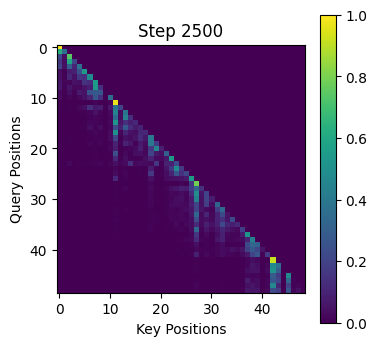

step 2500, train loss 3.1035, val loss 3.1732
step 2600, train loss 3.0301, val loss 3.1688
step 2700, train loss 3.0378, val loss 3.1584
step 2800, train loss 3.0709, val loss 3.1381
step 2900, train loss 3.0409, val loss 3.1357


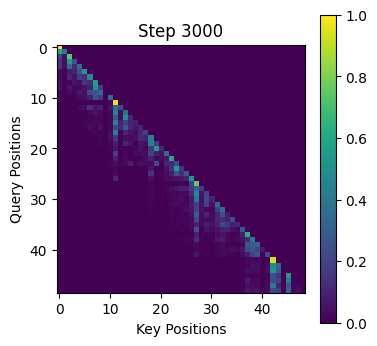

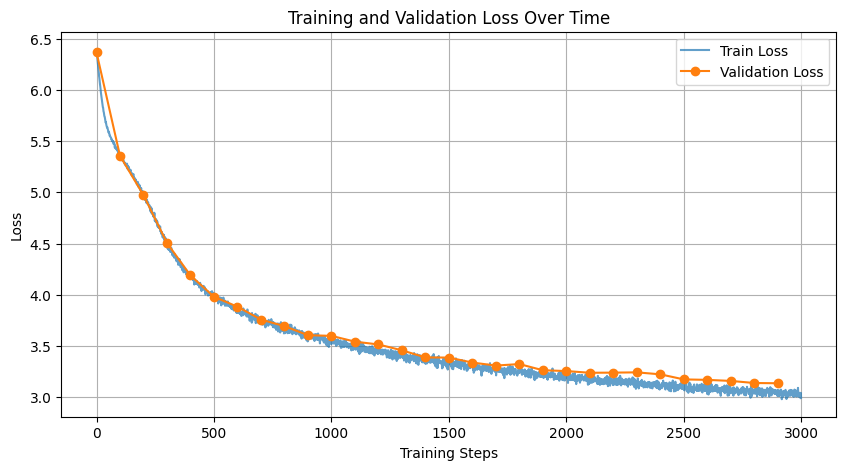

In [ ]:
# Arguments to modify: embedding_dim, n_heads, n_layers, lr (learning rate), and number of training steps

training_steps = 3000

model = TransformerLM(
    vocab_size=vocab_size, # fixed to 500
    embedding_dim=64,
    n_heads=4, # number of atttention heads
    n_layers=2 # number of TransformerBlock layers stacked
)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()


## Hook to store attention weights to plot Attention heatmaps

attention_weights = []
record_attention = False
def hook_fn(module, input, output):
    if record_attention:
        attention_weights.append(module.attn_weights.detach().cpu())
hook = model.blocks[0].attn.register_forward_hook(hook_fn) # Register hook on the first attention layer

# Get a sample sequence from validation
sample_idx = torch.randint(0, len(X_val), (1,)).item()
sample_x = X_val[sample_idx].unsqueeze(0)
print(sample_x)
# sample_string = ' '.join([vocab_list[i] for i in sample_x.squeeze().tolist()])
sample_string = tokenizer.decode(sample_x.squeeze().tolist()) # preserves correct word order
print("Sample token sequence used for attention heatmaps:\n", sample_string)


batch_size = 512

## Train

train_losses = []
val_losses = []

print("\nBegin training...")
for step in range(training_steps):

    # Sample random training sequence
    idx = torch.randint(0, len(X_train), (batch_size,))
    x_batch = X_train[idx]
    y_batch = y_train[idx]
    
    # Forward pass
    logits = model(x_batch)  # (B, T, vocab_size) # this calls forward under the hood using nn.Module 
    loss = loss_fn(logits.view(-1, logits.size(-1)), y_batch.view(-1))
    train_losses.append(loss.item())

    # Backpropagation and optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Compute validation loss on a random validation sequence
    if step % 100 == 0:
        # Sample random sequence
        val_idx = torch.randint(0, len(X_val), (batch_size,))
        x_val_batch = X_val[val_idx]
        y_val_batch = y_val[val_idx]
        
        with torch.no_grad():
            val_logits = model(x_val_batch)
            val_loss = loss_fn(val_logits.view(-1, val_logits.size(-1)), y_val_batch.view(-1))
        
        val_losses.append(val_loss.item()) # val_loss is a tensor, we need to convert it to a scalar using .item()
        print(f"step {step}, train loss {loss.item():.4f}, val loss {val_loss.item():.4f}")
    
    # Attention heatmaps
    if step == 0 or ((step+1) % 500 == 0): # every 500 steps # ALTERNATIVES: step >= training_steps - 100 (last 100 steps) or # step == training_steps - 1 (only in the last step)
        
        attention_weights.clear()
        
        # record attention for the sample sequence
        record_attention = True
        _ = model(sample_x)
        record_attention = False

        # Plot attention heatmap for the first head
        attn = attention_weights[-1][0, 0, :, :]  # (T, T) for first batch, first head (T = sequence length)
        plt.figure(figsize=(4, 4))
        plt.imshow(attn.cpu().numpy(), cmap='viridis')
        # plt.title(f'Attention Heatmap (First Head), Step {step}')
        plt.title(f'Step {step+1}')
        plt.xlabel('Key Positions')
        plt.ylabel('Query Positions')
        plt.colorbar()
        plt.show()

# Remove hook
hook.remove()

# Plot training and validation loss
steps = list(range(0, len(train_losses)))
val_steps = list(range(0, len(val_losses) * 100, 100))

plt.figure(figsize=(10, 5))
plt.plot(steps, train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_steps, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Evaluate Model

In [ ]:
## Save Trained Model
'''
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "vocab_size": 500,
        "embed_dim": 64,
        "num_heads": 4,
        "num_layers": 2
    }
}, "saved_model.pt")
'''

In [ ]:
## Load Saved Model
'''
saved_model = torch.load("saved_model.pt")

model = TransformerLM(**saved_model["config"])
model.load_state_dict(saved_model["model_state_dict"])
model.eval()
'''

In [57]:
## Compute Perplexity on validation set

def compute_perplexity(model, data, targets):
    model.eval()
    total_loss = 0
    count = 0
    with torch.no_grad():
        for i in range(len(data)):
            x_batch = data[i].unsqueeze(0)
            y_batch = targets[i].unsqueeze(0)
            logits = model(x_batch)
            loss = loss_fn(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            total_loss += loss.item() * x_batch.size(1)
            count += x_batch.size(1)
    avg_loss = total_loss / count
    ppl = math.exp(avg_loss)
    return ppl

val_ppl = compute_perplexity(model, X_val, y_val)
print(f"Validation Perplexity: {val_ppl:.2f}")



## Sample generations
def generate(model, start_tokens, max_len=50):
    model.eval()              ## trained neural network
    with torch.no_grad():
        x = torch.tensor(start_tokens).unsqueeze(0)
        for _ in range(max_len):
            logits = model(x)
            probs = torch.softmax(logits[:, -1, :], dim=-1)
            next_token = torch.multinomial(probs, 1)
            x = torch.cat([x, next_token], dim=1)
    return x.squeeze().tolist()

print("TEST")
# Start with some tokens, e.g., first 10 from val
start_tokens = X_val[0][:30].tolist()  # first sequence, first 10 tokens

generated_ids = generate(model, start_tokens, max_len=30)
generated_tokens = tokenizer.decode(generated_ids) # Decode to tokens

print("Start tokens:", tokenizer.decode(start_tokens))
print("Generated tokens:", generated_tokens)


Validation Perplexity: 22.92
TEST
Start tokens: 
First Murderer:
Take that, and that: if all this will not do,
I'll drown you
Generated tokens: 
First Murderer:
Take that, and that: if all this will not do,
I'll drown you, then I knctentity:
We would we with sent the reveniir to them all
A we his ceast


# Just for fun - Mini ChatGPT

In [68]:
prompt = input('What are you thinking?')

input_token_ids = tokenizer.encode(prompt).ids
generated_token_ids = generate(model, input_token_ids, max_len=30)
generated_tokens = tokenizer.decode(generated_token_ids)
print("User prompt:", prompt)
print("Mini GPT response:", generated_tokens)

User prompt: I like tomatoes, how about you?
Mini GPT response:  I like tomatoes, how about you?

Second Somenging it me not.

JULIET:
And, sir, Manthe.


# Comparing Effects of Hyperparameters

embedding_dim=32, lr=0.0001:
train loss 5.1107, val loss 5.1427, val perplexity 167.38


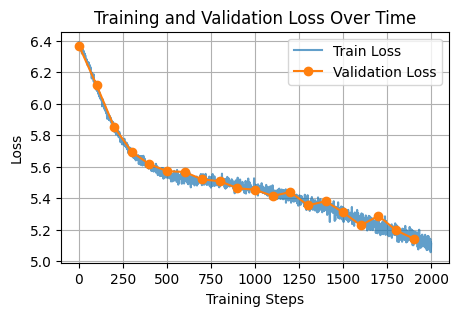

embedding_dim=32, lr=0.0005:
train loss 4.1991, val loss 4.2736, val perplexity 68.63


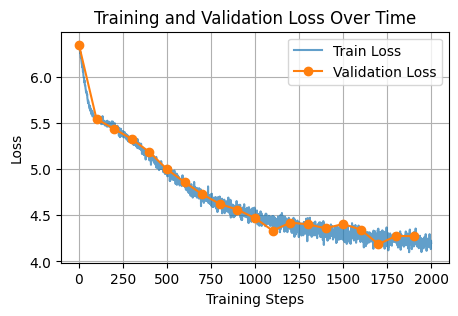

embedding_dim=32, lr=0.001:
train loss 4.1369, val loss 4.1518, val perplexity 58.41


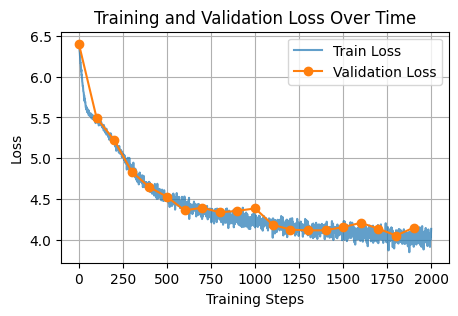

embedding_dim=64, lr=0.0001:
train loss 4.5381, val loss 4.4743, val perplexity 91.47


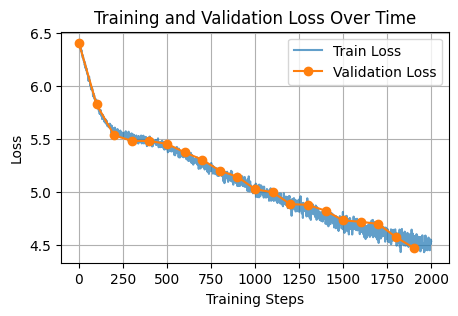

embedding_dim=64, lr=0.0005:
train loss 3.7658, val loss 3.8592, val perplexity 47.04


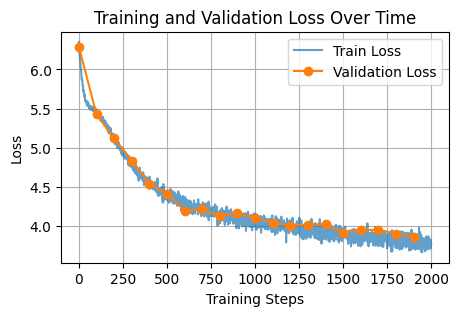

embedding_dim=64, lr=0.001:
train loss 3.4952, val loss 3.6652, val perplexity 39.43


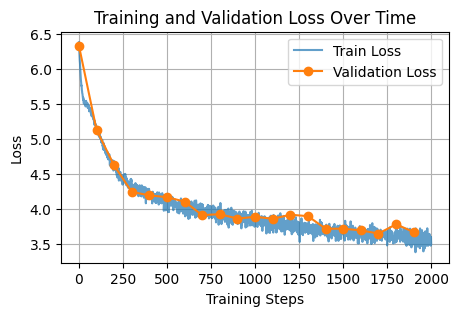

embedding_dim=128, lr=0.0001:
train loss 3.9284, val loss 4.1027, val perplexity 57.58


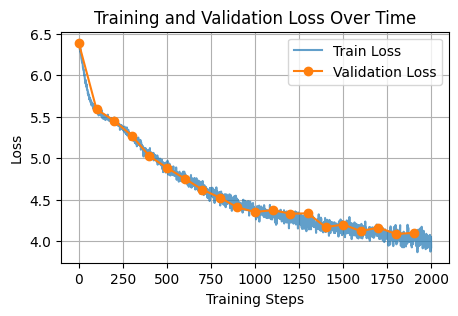

embedding_dim=128, lr=0.0005:
train loss 3.2019, val loss 3.5247, val perplexity 32.07


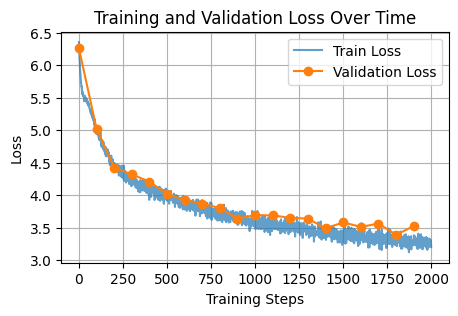

embedding_dim=128, lr=0.001:
train loss 2.9933, val loss 3.4175, val perplexity 29.14


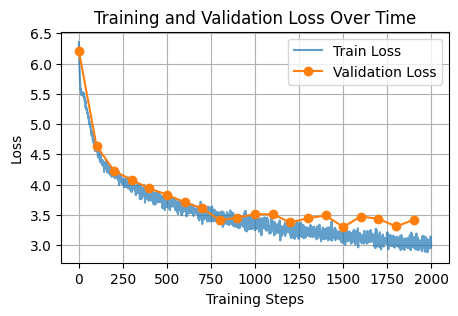

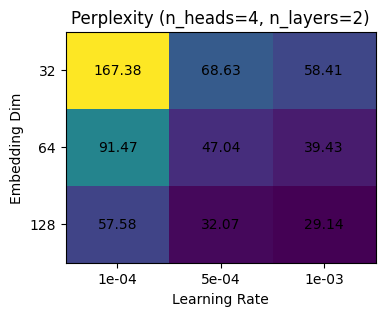

n_heads=2, n_layers=1:
train loss 3.8411, val loss 3.9889, val perplexity 52.05


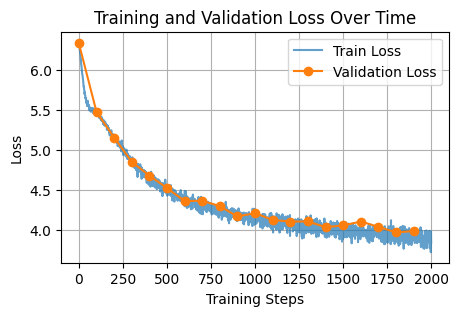

n_heads=2, n_layers=2:
train loss 3.7364, val loss 3.9308, val perplexity 47.00


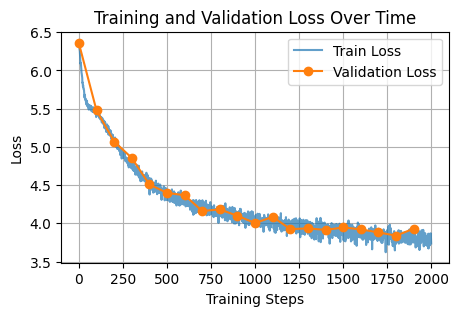

n_heads=2, n_layers=4:
train loss 3.4331, val loss 3.6998, val perplexity 41.72


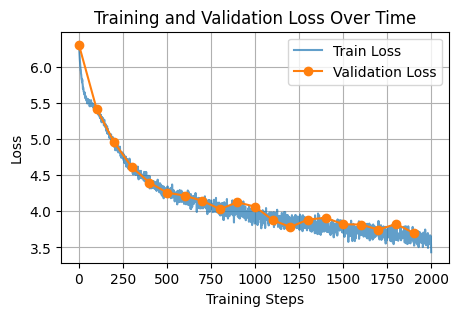

n_heads=4, n_layers=1:
train loss 3.9141, val loss 3.9887, val perplexity 51.82


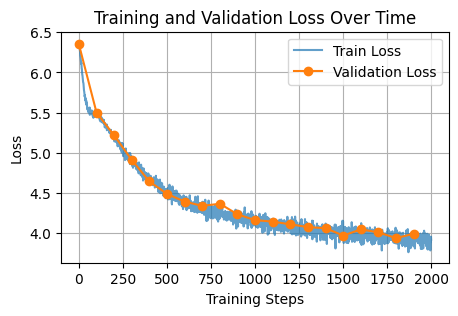

n_heads=4, n_layers=2:
train loss 3.7416, val loss 3.9208, val perplexity 46.74


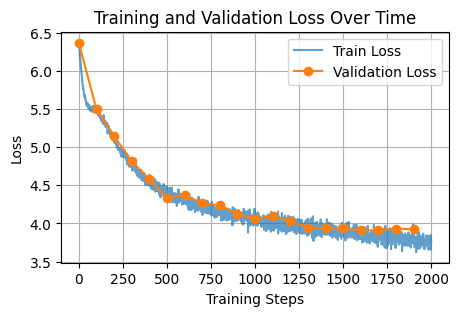

n_heads=4, n_layers=4:
train loss 3.6852, val loss 3.7889, val perplexity 43.02


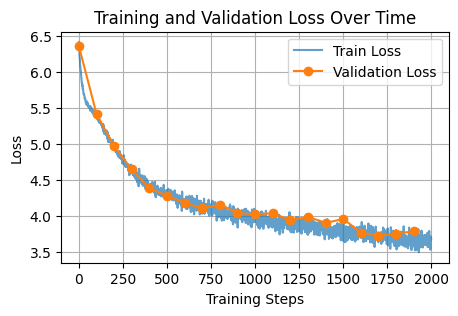

n_heads=8, n_layers=1:
train loss 3.8576, val loss 3.8736, val perplexity 52.10


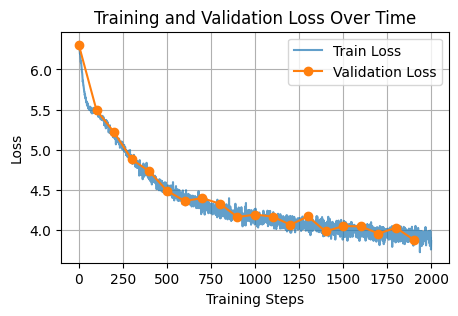

n_heads=8, n_layers=2:
train loss 3.7525, val loss 3.9427, val perplexity 47.86


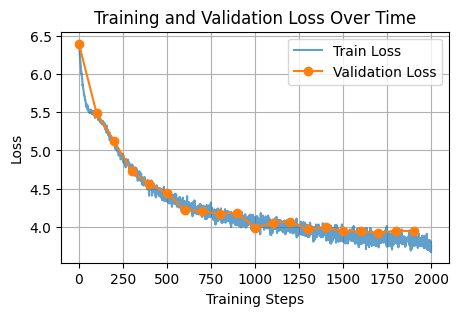

n_heads=8, n_layers=4:
train loss 3.7549, val loss 3.8402, val perplexity 44.00


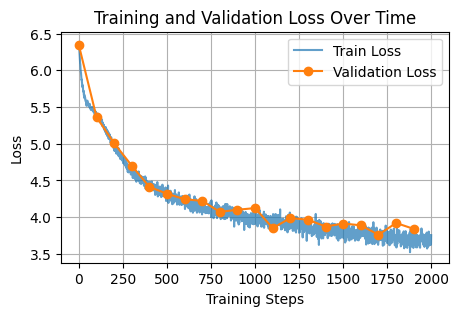

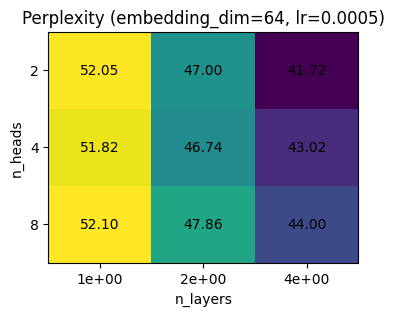

In [16]:
# Arguments to modify: embedding_dim, n_heads, n_layers, lr (learning rate), and number of training steps

batch_size = 64

def evaluate_stability(table, key, embedding_dim, n_heads, n_layers, lr):

    model = TransformerLM(
            vocab_size=vocab_size, # fixed to 500
            embedding_dim=embedding_dim,
            n_heads=n_heads,
            n_layers=n_layers
        )
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    ## Train
    train_losses = []
    val_losses = []

    for step in range(training_steps):
        idx = torch.randint(0, len(X_train), (batch_size,))
        x_batch = X_train[idx]
        y_batch = y_train[idx]
        
        # Forward pass
        logits = model(x_batch)  # (B, T, vocab_size) # this calls forward under the hood using nn.Module 
        loss = loss_fn(logits.view(-1, logits.size(-1)), y_batch.view(-1))
        train_losses.append(loss.item())

        # Backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Compute validation loss on a random validation sequence
        if step % 100 == 0:
            val_idx = torch.randint(0, len(X_val), (batch_size,))
            x_val_batch = X_val[val_idx]
            y_val_batch = y_val[val_idx]
            
            with torch.no_grad():
                val_logits = model(x_val_batch)
                val_loss = loss_fn(val_logits.view(-1, val_logits.size(-1)), y_val_batch.view(-1))
            
            val_losses.append(val_loss.item()) # val_loss is a tensor, we need to convert it to a scalar using .item()
    
    val_ppl = compute_perplexity(model, X_val, y_val)

    print(f"train loss {loss.item():.4f}, val loss {val_loss.item():.4f}, val perplexity {val_ppl:.2f}")

    # Store perplexities for tables
    table[key] = {"ppl": val_ppl}
    
    # Plot training and validation loss
    steps = list(range(0, len(train_losses)))
    val_steps = list(range(0, len(val_losses) * 100, 100))
    plt.figure(figsize=(5, 3))
    plt.plot(steps, train_losses, label='Train Loss', alpha=0.7)
    plt.plot(val_steps, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    return table

def plot_matrix(matrix, x_title, x_labels, y_title, y_labels, title, value_format="{:.2f}"):
    plt.figure(figsize=(4, 3))
    plt.imshow(matrix, cmap='viridis', aspect='auto')
    plt.xticks(range(len(x_labels)), [f'{x:.0e}' for x in x_labels])
    plt.yticks(range(len(y_labels)), y_labels)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            if not np.isnan(matrix[i, j]):
                plt.text(j, i, value_format.format(matrix[i, j]), ha='center', va='center', color='black')
    plt.show()



training_steps = 2000

## Test embedding_dim vs lr (fixed n_heads=4, n_layers=2)
table1 = {} # Dictionary to store perplexities

n_heads_test = 4
n_layers_test = 2
embedding_dims = [32, 64, 128]
lrs = [1e-4, 5e-4, 1e-3]

for embedding_dim_test in embedding_dims:
    for lr_test in lrs:
        print(f"embedding_dim={embedding_dim_test}, lr={lr_test}:")
        table1 = evaluate_stability(table1, (embedding_dim_test, lr_test), embedding_dim_test, n_heads_test, n_layers_test, lr_test)

ppl_matrix1 = np.array([[table1.get((emb, lr), {}).get("ppl", np.nan) for lr in lrs] for emb in embedding_dims])
plot_matrix(ppl_matrix1, 'Learning Rate', lrs, 'Embedding Dim', embedding_dims, 'Perplexity (n_heads=4, n_layers=2)')


## Test n_heads vs n_layers (fixed embedding_dim=64, lr=0.0005)
table2 = {}

heads = [2, 4, 8]
layers = [1, 2, 4]
embedding_dim_test = 64
lr_test = 0.0005

for n_heads_test in heads:
    for n_layers_test in layers:
        print(f"n_heads={n_heads_test}, n_layers={n_layers_test}:")
        table2 = evaluate_stability(table2, (n_heads_test, n_layers_test), embedding_dim_test, n_heads_test, n_layers_test, lr_test)

ppl_matrix2 = np.array([[table2.get((h, l), {}).get("ppl", np.nan) for l in layers] for h in heads])
plot_matrix(ppl_matrix2, 'n_layers', layers, 'n_heads', heads, 'Perplexity (embedding_dim=64, lr=0.0005)')
